In [190]:
import sklearn 
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from mpl_toolkits import mplot3d
from sklearn.metrics import pairwise_distances_argmin
#you can use Python’s imaging library (PIL)
from PIL import Image
from IPython.display import display
# or you can use opencv ## conda install anaconda::opencv
import cv2 #if you use cv2 remember to convert from BGR to RGB
import scipy.cluster.hierarchy as sch #you only for sch.dendrogram


# Loading and Plotting Data

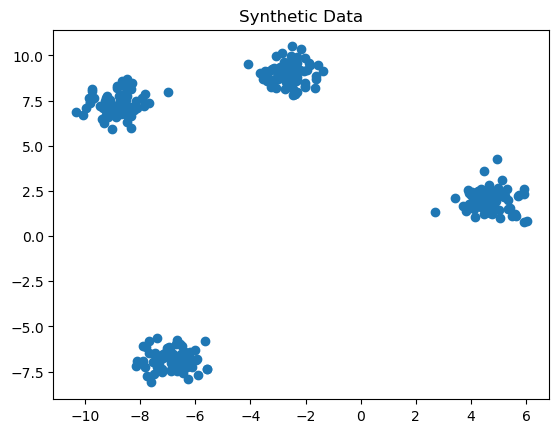

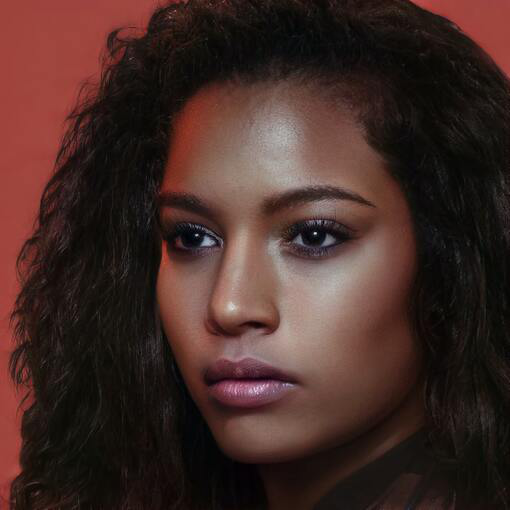

In [191]:
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)

lady = "cropped.jpg"
img = Image.open(lady)
img = img.convert('RGB')
rgb = np.array(img).reshape((-1,3))

# print(rgb)

#plotting the data
plt.scatter(X[:, 0], X[:, 1])
plt.title("Synthetic Data")
plt.show()

display(img)

# Implement K-means

In [192]:
def assign_clusters(X, centroids):
    return pairwise_distances_argmin(X, centroids)

def update_centroids(X, labels, k):
    new_centroids = []

    for i in range(k):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            cluster_mean = cluster_points.mean(axis=0)
        else:
            cluster_mean = np.random.rand(X.shape[1])

        new_centroids.append(cluster_mean)

    return np.array(new_centroids)
    
def k_means(X, k, seed=None, init="random"):
    if seed is not None:
        np.random.seed(seed)
        
    #random or kmeans++ initialization
    if init == "random":
        indices = np.random.choice(X.shape[0], k, replace=False)
        centroids = X[indices]
    elif init == "kmeans++":
        centroids = k_means_plus_plus(X, k, seed)

    #print(centroids)
    
    for i in range(100):
        old_centroids = centroids
        labels = assign_clusters(X, centroids)
        centroids = update_centroids(X, labels, k)

    return centroids, labels


In [193]:
def plot_clusters(X, centroids, labels):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(211)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis")
    ax.scatter(centroids[:, 0], centroids[:, 1], c="red")
    plt.show()

def display_image(rgb, centroids):
    closest = pairwise_distances_argmin(rgb, centroids)
    compressed_img = np.array([centroids[i] for i in closest])
    compressed_img = compressed_img.astype(np.uint8).reshape(img.size[1], img.size[0], 3)
    compressed_img = Image.fromarray(compressed_img)
    display(compressed_img)

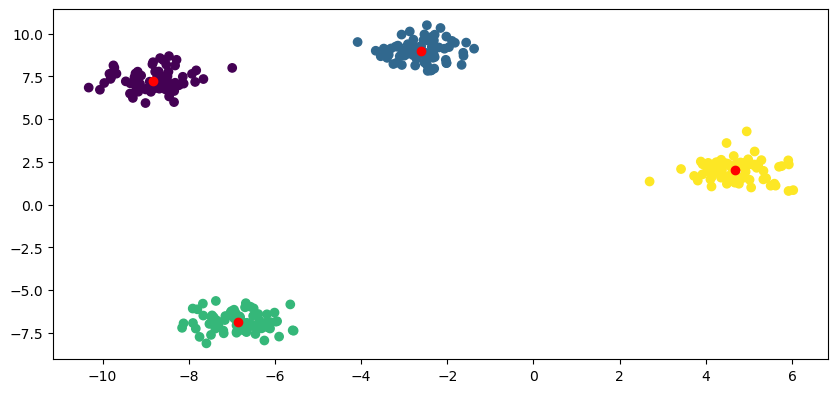

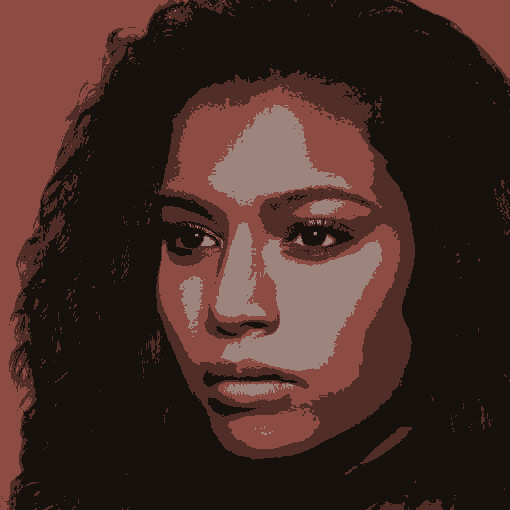

In [194]:
#With default seed
num_centroids = 4

centroids, labels = k_means(X, num_centroids)
plot_clusters(X, centroids, labels)

centroids_img, labels_img = k_means(rgb, num_centroids)
display_image(rgb, centroids_img)

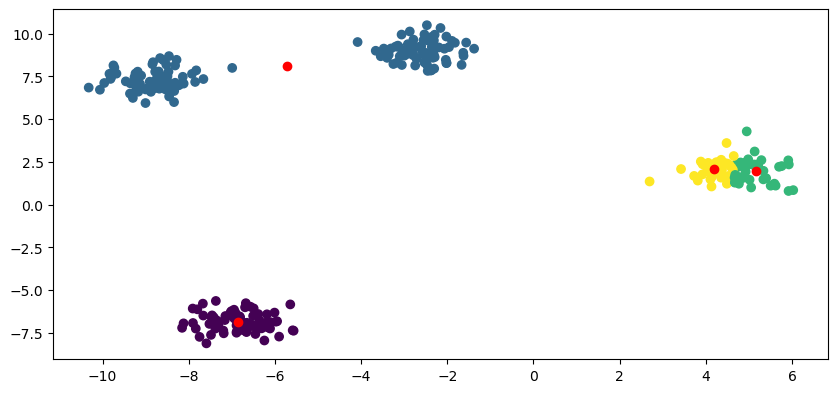

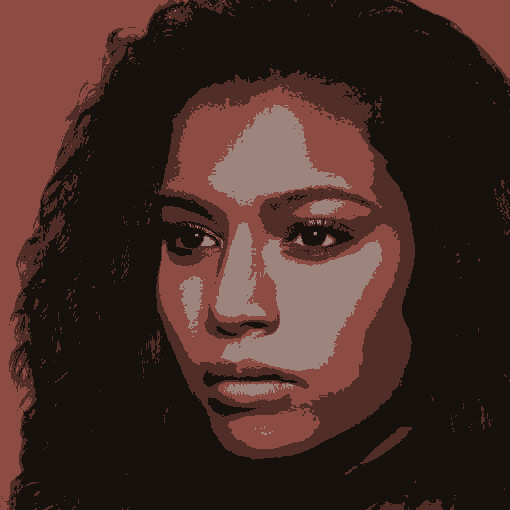

In [195]:
#With seed=2
centroids, labels = k_means(X, num_centroids, seed=2)
plot_clusters(X, centroids, labels)

centroids_img, labels_img = k_means(rgb, num_centroids, seed=2)
display_image(rgb, centroids_img)


# Kmeans++

In [196]:
def k_means_plus_plus(X, k, seed=None):
    if seed is not None:
        np.random.seed(seed)
    centroids = [X[np.random.randint(X.shape[0])]]

    for i in range(1, k):
        distances = np.array([min(np.sum((x - c) ** 2) for c in centroids) for x in X])
        probabilities = distances / np.sum(distances)
        
        next_centroid = X[np.random.choice(X.shape[0], p=probabilities)]
        centroids.append(next_centroid)

    return np.array(centroids)


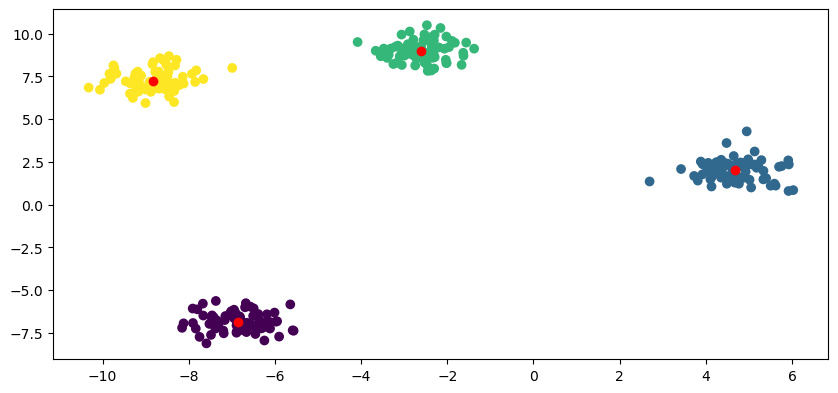

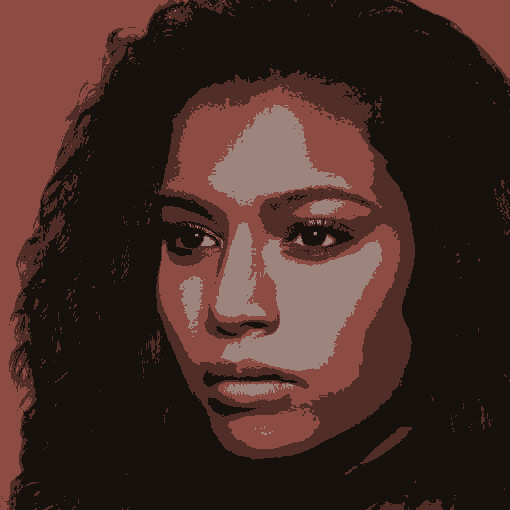

In [197]:
#With default seed
centroids, labels = k_means(X, num_centroids, init="kmeans++")
plot_clusters(X, centroids, labels)

centroids_img, labels_img = k_means(rgb, num_centroids, init='kmeans++' )
display_image(rgb, centroids_img)

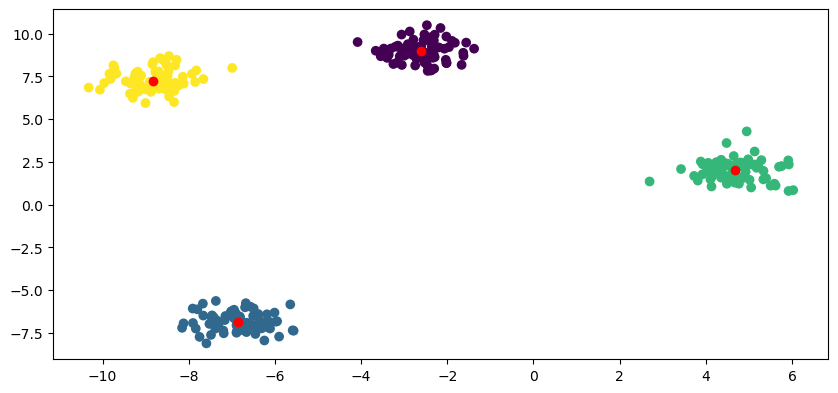

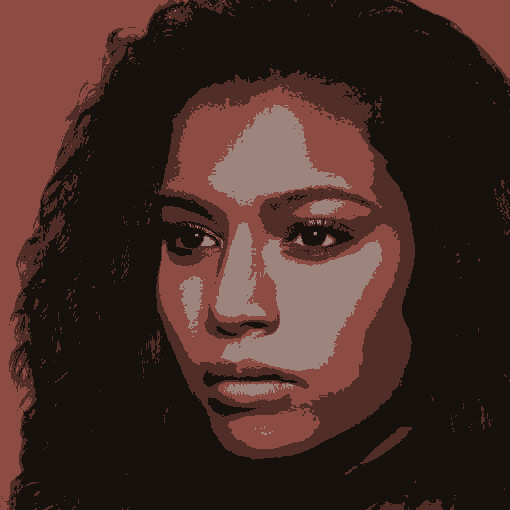

In [198]:
#With seed=2
centroids, labels = k_means(X, num_centroids, seed=2, init="kmeans++")
plot_clusters(X, centroids, labels)

centroids_img, labels_img = k_means(rgb, num_centroids, seed=2, init='kmeans++' )
display_image(rgb, centroids_img)

<span style="color:red">
    From the 4,5,6 and 7, which are the clustering results using kmeans and kmeans++ with default and specified seed, showcases visible differences between kmeans and kmeans++. This is basically the main difference. Here kmeans++ tends to be more consistant across different runs compared to the kmeans due to its centroids initialization. At the same time, different seeds also make difference in kmeans clustering. Sometimes, some specific seed may give a good clustering result but still it's not efficient, whereas kmeans++ reduces this dependency on the seeds and provides a better initialization of centroids. <span/>

In [187]:
# Load the Mall Customers dataset
mall_data = pd.read_csv('Mall_Customers.csv')

# Selecting relevant features for clustering
X_mall = mall_data.iloc[:, [3, 4]].values  # Using "Annual Income" and "Spending Score"


# Hierarchical Cluatering

In [209]:
def squared_euclidean_distance(x1, x2):
    return sum((x1[i] - x2[i])**2 for i in range(len(x1)))

def ward_distance(points, cluster_a, cluster_b):
    points_a = points[cluster_a]
    points_b = points[cluster_b]
    points_ab = np.vstack((points_a, points_b))

    #centroids
    cent_a = np.mean(points_a, axis=0)
    cent_b = np.mean(points_b, axis=0)
    cent_ab = np.mean(points_ab, axis=0)

    sum_dist_ab = sum(squared_euclidean_distance(p, cent_ab) for p in points_ab)
    sum_dist_a = sum(squared_euclidean_distance(p, cent_a) for p in points_a)
    sum_dist_b = sum(squared_euclidean_distance(p, cent_b) for p in points_b)

    return sum_dist_ab - sum_dist_a - sum_dist_b

def initialize_clusters(points):
    clusters = {i: [i] for i in range(len(points))}
    largest_id = len(points)-1
    distances = {}

    for i in range(len(points)):
        for j in range(i+1, len(points)):
            distances[(i, j)] = ward_distance(points, [i], [j])

    return clusters,distances, largest_id

def merge_clusters(points, clusters, distances, largest_id):
    cluster_pair = min(distances, key=distances.get)

    cluster_0, cluster_1 = clusters.pop(cluster_pair[0]), clusters.pop(cluster_pair[1])
    largest_id += 1
    clusters[largest_id] = cluster_0+cluster_1 

    distance = ward_distance(points, cluster_0, cluster_1)

    return cluster_pair, clusters, largest_id, distance

def update_distances(points, clusters, distances, largest_id, cluster_pair):
    for pair in list(distances.keys()):
        if cluster_pair[0] in pair or cluster_pair[1] in pair:
            del distances[pair]
    for c in clusters.keys():
        if c != largest_id:
            new_dist = ward_distance(points, clusters[largest_id], clusters[c])
            distances[(min(largest_id, c), max(largest_id, c))] = new_dist
            
def hierarchical_clustering(points):
    clusters, distances, largest_id = initialize_clusters(points)
    matrix = []

    while len(clusters) > 1:
        cluster_pair, clusters, largest_id, distance = merge_clusters(points, clusters, distances, largest_id)
        matrix.append([float(cluster_pair[0]), float(cluster_pair[1]), distance, len(clusters[largest_id])])
        update_distances(points, clusters, distances, largest_id, cluster_pair)

    return np.array(matrix)


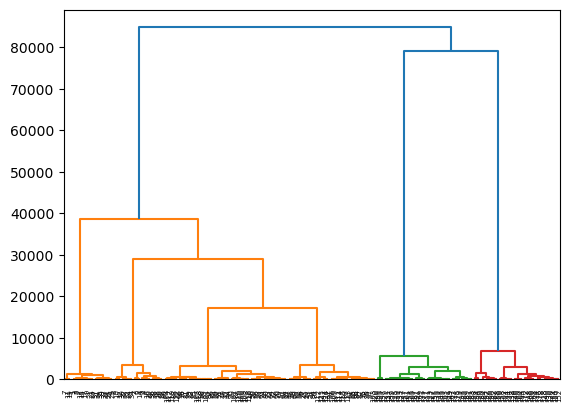

In [212]:
df = pd.read_csv("Mall_Customers.csv")
df["Gender"] = df["Gender"].map({"Male": 1, "Female": -1})
df = df.drop("CustomerID", axis=1)

points = df.to_numpy()
clustering = hierarchical_clustering(points)

plt.figure()
sch.dendrogram(clustering)
plt.show()
